<a href="https://colab.research.google.com/github/gardenstorm/Genshin-Wish-Visualization/blob/main/Genshin_Wish_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌠 Genshin Wish Visualization
As a version 1.1 player, I have over 5 years of wish data that I have been recording. Inspired by the website Paimon.moe, I want to create my own visualizations of my wish data. I have tried making some charts and pivot tables in Excel, but wasn't satisfied. So I wanted to do this the fun way: with Python. 😎

## 📊 The Data
There are 2 sets of data:

1. An Excel spreadsheet I created:
- Started in 2020
- Has only the date for timestamp
- Character name instead of full banner name
- I stopped using some columns
- Until January 2025


2. An Excel spreadsheet exported from paimon.moe:
- Started using the site in 2021
- List of banner names
- Complete timestamps
- Group column (10 pull batches)
- Up to late February 2026

## What I Want to Visualize
- How many 5 stars I have ✅
- What 4 stars I get the most ✅
- What weapon I get the most ✅
- My win rate ✅
- How many early 5 stars ✅
- My average pity ✅


## 🛠️ Putting together the data
According to my data, I started using Paimon.moe in August of 2021. So from my personal spreadsheet I will add data from before that date onto to the Paimon.moe one.

I will use the columns both datasets have in common in the order Paimon.moe has:
- Type: Character or weapon
- Name
- Time
- ⭐: Rarity, goes from 3-5
- Pity: 4 star pity count
- Roll #: 5 star pity count
- Banner

Maybe keep the Wish # column from my personal spreadsheet? It's fun to see that count. (It's in the thousands!)

Naturally, I will need to reorder my personal spreadsheet columns.

Tools used:
- Python
 - Pandas
- Google Drive
- Google Colab
- Google Sheets

File names:
- paimonmoe_wish_history.xlsx
- Genshin Wish Tracker.xlsx

In [2]:
import pandas as pd
import numpy as np

### My personal Excel sheet

- Loading the Excel file
- Only using rows up to August 2021 with `.head()`
- Setting the 1st row as the header and "Wish #" as index column
- Dropping columns I'm not using

In [3]:
# load the Excel file and start a df
personal = pd.ExcelFile('/content/drive/MyDrive/Genshin Wish Tracker.xlsx')
ps_limited = pd.read_excel(personal, sheet_name='Event Banner', header=1, index_col=0).head(225).drop(columns=['Notes', '10 Pull?'])
ps_limited

,Wish Date,Type,Wish Result,Rarity,Banner,4¶ Pity,5¶ Pity
Wish #,,,,,,,
1,2020-12-16 00:00:00,Character,Beidou,4,Zhongli 1st,1.0,1
2,2020-12-16 00:00:00,Weapon,Harbinger of Dawn,3,Zhongli 1st,NaN,2
3,2020-12-16 00:00:00,Weapon,Harbinger of Dawn,3,Zhongli 1st,NaN,3
4,2020-12-18 00:00:00,Weapon,Raven Bow,3,Zhongli 1st,NaN,4
5,2020-12-18 00:00:00,Weapon,Harbinger of Dawn,3,Zhongli 1st,NaN,5
...,...,...,...,...,...,...,...
221,2021-05-15 00:00:00,Character,Bennett,4,Zhongli 2nd,5.0,75
222,2021-05-15 00:00:00,Character,Qiqi,5,Zhongli 2nd,1.0,76
223,2021-05-17 00:00:00,Weapon,Magic Guide,3,Zhongli 2nd,1.0,1


Reordering the columns

In [4]:
# List of column names to copy and paste
ps_limited.columns.values

array(['Wish Date', 'Type', 'Wish Result', 'Rarity', 'Banner', '4¶ Pity',
       '5¶  Pity'], dtype=object)

In [5]:
ps_limited_ro = ps_limited[['Type', 'Wish Result', 'Wish Date', 'Rarity', '4¶ Pity', '5¶  Pity', 'Banner']]
ps_limited_ro

,Type,Wish Result,Wish Date,Rarity,4¶ Pity,5¶ Pity,Banner
Wish #,,,,,,,
1,Character,Beidou,2020-12-16 00:00:00,4,1.0,1,Zhongli 1st
2,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,NaN,2,Zhongli 1st
3,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,NaN,3,Zhongli 1st
4,Weapon,Raven Bow,2020-12-18 00:00:00,3,NaN,4,Zhongli 1st
5,Weapon,Harbinger of Dawn,2020-12-18 00:00:00,3,NaN,5,Zhongli 1st
...,...,...,...,...,...,...,...
221,Character,Bennett,2021-05-15 00:00:00,4,5.0,75,Zhongli 2nd
222,Character,Qiqi,2021-05-15 00:00:00,5,1.0,76,Zhongli 2nd
223,Weapon,Magic Guide,2021-05-17 00:00:00,3,1.0,1,Zhongli 2nd


Renaming the columns to:
- match the paimon.moe sheet
- have more intuitive names

In [6]:
ps_limited_almost = ps_limited_ro.rename(index=str, columns={'Wish Date': 'Time', '4¶ Pity': '4⭐ Pity', '5¶  Pity': '5⭐ Pity'})
ps_limited_almost

,Type,Wish Result,Time,Rarity,4⭐ Pity,5⭐ Pity,Banner
Wish #,,,,,,,
1,Character,Beidou,2020-12-16 00:00:00,4,1.0,1,Zhongli 1st
2,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,NaN,2,Zhongli 1st
3,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,NaN,3,Zhongli 1st
4,Weapon,Raven Bow,2020-12-18 00:00:00,3,NaN,4,Zhongli 1st
5,Weapon,Harbinger of Dawn,2020-12-18 00:00:00,3,NaN,5,Zhongli 1st
...,...,...,...,...,...,...,...
221,Character,Bennett,2021-05-15 00:00:00,4,5.0,75,Zhongli 2nd
222,Character,Qiqi,2021-05-15 00:00:00,5,1.0,76,Zhongli 2nd
223,Weapon,Magic Guide,2021-05-17 00:00:00,3,1.0,1,Zhongli 2nd


Filling in 4⭐Pity's `NaN` values with `.interpolate()` and keeping the data type as INT with `.astype()`

In [7]:
ps_limited_almost['4⭐ Pity'] = ps_limited_almost['4⭐ Pity'].interpolate(method='linear').astype(int)
ps_limited_almost

,Type,Wish Result,Time,Rarity,4⭐ Pity,5⭐ Pity,Banner
Wish #,,,,,,,
1,Character,Beidou,2020-12-16 00:00:00,4,1,1,Zhongli 1st
2,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,1,2,Zhongli 1st
3,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,2,3,Zhongli 1st
4,Weapon,Raven Bow,2020-12-18 00:00:00,3,3,4,Zhongli 1st
5,Weapon,Harbinger of Dawn,2020-12-18 00:00:00,3,4,5,Zhongli 1st
...,...,...,...,...,...,...,...
221,Character,Bennett,2021-05-15 00:00:00,4,5,75,Zhongli 2nd
222,Character,Qiqi,2021-05-15 00:00:00,5,1,76,Zhongli 2nd
223,Weapon,Magic Guide,2021-05-17 00:00:00,3,1,1,Zhongli 2nd


Convert "Time" column to datetime to make filtering and searching easier

In [8]:
ps_limited_almost["Time"] = pd.to_datetime(ps_limited_almost["Time"], format='%Y-%m-%d %H:%M:%S')
ps_limited_almost

,Type,Wish Result,Time,Rarity,4⭐ Pity,5⭐ Pity,Banner
Wish #,,,,,,,
1,Character,Beidou,2020-12-16,4,1,1,Zhongli 1st
2,Weapon,Harbinger of Dawn,2020-12-16,3,1,2,Zhongli 1st
3,Weapon,Harbinger of Dawn,2020-12-16,3,2,3,Zhongli 1st
4,Weapon,Raven Bow,2020-12-18,3,3,4,Zhongli 1st
5,Weapon,Harbinger of Dawn,2020-12-18,3,4,5,Zhongli 1st
...,...,...,...,...,...,...,...
221,Character,Bennett,2021-05-15,4,5,75,Zhongli 2nd
222,Character,Qiqi,2021-05-15,5,1,76,Zhongli 2nd
223,Weapon,Magic Guide,2021-05-17,3,1,1,Zhongli 2nd


Remove 1st, 2nd, etc. from banner names

In [9]:
ps_limited_almost['Banner'] = ps_limited_almost['Banner'].str.replace(r"\s\d[a-z]+", "", regex=True)
ps_limited_almost

,Type,Wish Result,Time,Rarity,4⭐ Pity,5⭐ Pity,Banner
Wish #,,,,,,,
1,Character,Beidou,2020-12-16,4,1,1,Zhongli
2,Weapon,Harbinger of Dawn,2020-12-16,3,1,2,Zhongli
3,Weapon,Harbinger of Dawn,2020-12-16,3,2,3,Zhongli
4,Weapon,Raven Bow,2020-12-18,3,3,4,Zhongli
5,Weapon,Harbinger of Dawn,2020-12-18,3,4,5,Zhongli
...,...,...,...,...,...,...,...
221,Character,Bennett,2021-05-15,4,5,75,Zhongli
222,Character,Qiqi,2021-05-15,5,1,76,Zhongli
223,Weapon,Magic Guide,2021-05-17,3,1,1,Zhongli


Change VENTI to Venti

In [10]:
ps_limited_almost['Wish Result'] = ps_limited_almost['Wish Result'].str.replace('VENTI', 'Venti')
ps_limited_almost

,Type,Wish Result,Time,Rarity,4⭐ Pity,5⭐ Pity,Banner
Wish #,,,,,,,
1,Character,Beidou,2020-12-16,4,1,1,Zhongli
2,Weapon,Harbinger of Dawn,2020-12-16,3,1,2,Zhongli
3,Weapon,Harbinger of Dawn,2020-12-16,3,2,3,Zhongli
4,Weapon,Raven Bow,2020-12-18,3,3,4,Zhongli
5,Weapon,Harbinger of Dawn,2020-12-18,3,4,5,Zhongli
...,...,...,...,...,...,...,...
221,Character,Bennett,2021-05-15,4,5,75,Zhongli
222,Character,Qiqi,2021-05-15,5,1,76,Zhongli
223,Weapon,Magic Guide,2021-05-17,3,1,1,Zhongli


### Paimon.moe Excel sheet

🧚Paimon.moe data loaded, sans unused columns

In [11]:
paimon = pd.ExcelFile('/content/drive/MyDrive/paimonmoe_wish_history.xlsx')
pm_limited = pd.read_excel(paimon, sheet_name='Character Event').drop(columns=['Group', 'Part'])
pm_limited

,Type,Name,Time,⭐,Pity,#Roll,Banner
0,Character,Beidou,2020-12-16 16:51:04,4,1,1,Gentry of Hermitage
1,Weapon,Harbinger of Dawn,2020-12-16 16:51:47,3,1,2,Gentry of Hermitage
2,Weapon,Harbinger of Dawn,2020-12-16 16:53:11,3,1,3,Gentry of Hermitage
3,Weapon,Raven Bow,2020-12-18 16:53:41,3,1,4,Gentry of Hermitage
4,Weapon,Harbinger of Dawn,2020-12-18 16:54:13,3,1,5,Gentry of Hermitage
...,...,...,...,...,...,...,...
1774,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,6,Decree of the Deeps
1775,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,7,Decree of the Deeps
1776,Weapon,Debate Club,2026-02-05 20:31:59,3,1,8,Decree of the Deeps
1777,Weapon,Slingshot,2026-02-05 20:31:59,3,1,9,Decree of the Deeps


Removing columns before August 2021 and converting the "Time" column to datetime

In [12]:
# convert "Time" col to datetime
pm_limited['Time'] = pd.to_datetime(pm_limited['Time'], format='%Y-%m-%d %H:%M:%S')

# filter out lines from before August 2021
pm_limited_filtered = pm_limited.query("Time >= '2021-08-01'")
pm_limited_filtered

,Type,Name,Time,⭐,Pity,#Roll,Banner
11,Weapon,Bloodtainted Greatsword,2021-08-12 14:06:37,3,1,1,Tapestry of Golden Flames
12,Weapon,Raven Bow,2021-08-12 14:06:48,3,1,2,Tapestry of Golden Flames
13,Weapon,Magic Guide,2021-08-12 14:07:00,3,1,3,Tapestry of Golden Flames
14,Character,Xinyan,2021-08-12 14:07:20,4,4,4,Tapestry of Golden Flames
15,Weapon,Harbinger of Dawn,2021-08-12 17:47:22,3,1,5,Tapestry of Golden Flames
...,...,...,...,...,...,...,...
1774,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,6,Decree of the Deeps
1775,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,7,Decree of the Deeps
1776,Weapon,Debate Club,2026-02-05 20:31:59,3,1,8,Decree of the Deeps
1777,Weapon,Slingshot,2026-02-05 20:31:59,3,1,9,Decree of the Deeps


Change the formal banner names to character names
- More intuitive for me
- Will fit in visualizations better

In [13]:
# load the csv into a df
banner_csv = pd.read_csv('/content/drive/MyDrive/Genshin Banners.csv')

# set "Name" col as the index
banner_dict = banner_csv.set_index('Name')

# turn the df into a dict
banner_dict = banner_dict['Character'].to_dict()

# make the swaps!
pm_limited_filtered = pm_limited_filtered.copy()
pm_limited_filtered.loc[:, 'Banner'] = pm_limited_filtered['Banner'].map(banner_dict)
pm_limited_filtered

,Type,Name,Time,⭐,Pity,#Roll,Banner
11,Weapon,Bloodtainted Greatsword,2021-08-12 14:06:37,3,1,1,Yoimiya
12,Weapon,Raven Bow,2021-08-12 14:06:48,3,1,2,Yoimiya
13,Weapon,Magic Guide,2021-08-12 14:07:00,3,1,3,Yoimiya
14,Character,Xinyan,2021-08-12 14:07:20,4,4,4,Yoimiya
15,Weapon,Harbinger of Dawn,2021-08-12 17:47:22,3,1,5,Yoimiya
...,...,...,...,...,...,...,...
1774,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,6,Neuvillette
1775,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,7,Neuvillette
1776,Weapon,Debate Club,2026-02-05 20:31:59,3,1,8,Neuvillette
1777,Weapon,Slingshot,2026-02-05 20:31:59,3,1,9,Neuvillette


Change the column names to match `ps_limited_almost`

In [14]:
pm_limited_filtered = pm_limited_filtered.rename(index=str, columns={'Name' : 'Wish Result', '⭐': 'Rarity', 'Pity': '4⭐ Pity', '#Roll': '5⭐ Pity'})
pm_limited_filtered

,Type,Wish Result,Time,Rarity,4⭐ Pity,5⭐ Pity,Banner
11,Weapon,Bloodtainted Greatsword,2021-08-12 14:06:37,3,1,1,Yoimiya
12,Weapon,Raven Bow,2021-08-12 14:06:48,3,1,2,Yoimiya
13,Weapon,Magic Guide,2021-08-12 14:07:00,3,1,3,Yoimiya
14,Character,Xinyan,2021-08-12 14:07:20,4,4,4,Yoimiya
15,Weapon,Harbinger of Dawn,2021-08-12 17:47:22,3,1,5,Yoimiya
...,...,...,...,...,...,...,...
1774,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,6,Neuvillette
1775,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,7,Neuvillette
1776,Weapon,Debate Club,2026-02-05 20:31:59,3,1,8,Neuvillette
1777,Weapon,Slingshot,2026-02-05 20:31:59,3,1,9,Neuvillette


Combine the data frames with `concat()`

In [15]:
ps_limited_almost = ps_limited_almost.reset_index(drop=True)
wish_data = pd.concat([ps_limited_almost, pm_limited_filtered]).reset_index(drop=True)
wish_data

,Type,Wish Result,Time,Rarity,4⭐ Pity,5⭐ Pity,Banner
0,Character,Beidou,2020-12-16 00:00:00,4,1,1,Zhongli
1,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,1,2,Zhongli
2,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,2,3,Zhongli
3,Weapon,Raven Bow,2020-12-18 00:00:00,3,3,4,Zhongli
4,Weapon,Harbinger of Dawn,2020-12-18 00:00:00,3,4,5,Zhongli
...,...,...,...,...,...,...,...
1986,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,6,Neuvillette
1987,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,7,Neuvillette
1988,Weapon,Debate Club,2026-02-05 20:31:59,3,1,8,Neuvillette
1989,Weapon,Slingshot,2026-02-05 20:31:59,3,1,9,Neuvillette


## 🔎Processing the Data

### How many 5 star characters from limited banners

In [16]:
# how many 5 stars I've pulled from event banners
ssr = wish_data[wish_data['Rarity'] == 5]
ssr['Wish Result'].nunique()

23

In [17]:
# list of 5 star characters and times pulled
ssr['Wish Result'].value_counts()

,count
Wish Result,
Keqing,6
Diluc,2
Wanderer,2
Qiqi,1
Raiden Shogun,1
Ganyu,1
Venti,1
Zhongli,1
Albedo,1


### Most pulled weapons

In [18]:
# most pulled weapons
weapons = wish_data[wish_data['Type'] == 'Weapon']
weapons['Wish Result'].value_counts()

,count
Wish Result,
Sharpshooter's Oath,147
Raven Bow,142
Ferrous Shadow,139
Thrilling Tales of Dragon Slayers,137
Cool Steel,136
Black Tassel,133
Skyrider Sword,129
Harbinger of Dawn,123
Debate Club,123


### Most pulled 4 stars

In [19]:
# most pulled 4 star weapons
weapons = wish_data[(wish_data['Type'] == 'Weapon') & (wish_data['Rarity'] == 4)]
weapons['Wish Result'].value_counts()

,count
Wish Result,
The Stringless,7
Dragon's Bane,6
Sacrificial Bow,6
Favonius Lance,6
Rainslasher,5
Rust,5
The Bell,5
Sacrificial Greatsword,4
The Widsith,4


In [20]:
# now let's get characters
characters = wish_data[(wish_data['Type'] == 'Character') & (wish_data['Rarity'] == 4)]
characters['Wish Result'].value_counts()

,count
Wish Result,
Beidou,16
Yanfei,12
Diona,11
Sucrose,11
Faruzan,11
Bennett,10
Noelle,8
Xiangling,8
Fischl,7


### 50/50 luck

In [21]:
# Claude helped with the formula. I came up with the True/False table!
wins = (ssr['Wish Result'] == ssr['Banner']) == True
wins_values = wins.value_counts()
win_rate_5stars = (wins_values[True] - wins_values[False]) / wins_values[True] * 100
win_rate_5stars

np.float64(50.0)

In [22]:
wins_values

,count
True,20
False,10


### Early 5 stars
According to [game8](https://game8.co/games/Genshin-Impact/archives/305937), Genshin's pity system has soft pity between pulls 60 - 80. Hard pity is after 80, and if a 5 star character on the limited banner is guranteed at 90 pity if one isn't received earlier. So, we count 5 stars before hard pity as "early". The earlier the 5 star, the more exciting it is!

I chose 70 as a midpoint between 60 and 80.

#### ⚠️ Note:
I misinterpreted what 2 of Paimon.moe's columns meant here and need to rename them to what they were originally: `Pity` and `#Roll`.
- `Pity` is the pity count for both 4 and 5 stars.
- `#Roll` is the number of rolls on the banner.
  - I want to rename this column to something clearer.

In [23]:
early_5s = ssr[(ssr['4⭐ Pity'] < 70)].drop(columns=['Type', 'Time', 'Rarity', '5⭐ Pity'])
early_5s

,Wish Result,4⭐ Pity,Banner
64,Keqing,6,Ganyu
66,Ganyu,2,Ganyu
139,Venti,8,Venti
221,Qiqi,1,Zhongli
847,Keqing,16,Ayaka
1352,Wanderer,52,Wanderer
1532,Kinich,29,Kinich
1736,Skirk,51,Skirk
1990,Dehya,10,Neuvillette


### Average Pity
Pretty simple: The average of the Pity column.

In [24]:
avg_pity = ssr['4⭐ Pity'].mean().astype(int)
avg_pity

np.int64(59)

My pity doesn't feel that good most of the time. Let's try mode and median.

In [25]:
med_pity = ssr['4⭐ Pity'].median()
med_pity

75.5

In [26]:
mode_pity = ssr['4⭐ Pity'].mode()
mode_pity

,4⭐ Pity
0,76


That's closer to what I feel most of the time: 75 or 76 pulls.

## ⏩ Refactoring to go faster
Now that I hashed out my data, let's make the code more functional and pythonic.

Functions:
1. Loading the Excel sheet and general adjustments
2. Banner column stuff
3. Merging
4. My 6 questions

The other code is too finicky to put into functions.

### 🕑 Loading the Excel sheet
- Docstring to specify Excel file only
- Parameters:
  - `file`, `sheet_name`, `drop_columns`, `time_convert`

In [27]:
import pandas as pd

# loading the Excel sheet
def load_file(file: str, sheet: str, drop_columns: list[str], time_convert: str, num_rows: int = None, header: int = 0) -> pd.DataFrame:
  """Loads the Excel file, selects the relevant sheet,
  drops unused columns, and converts one column to datetime.
  > file: Excel file to load as a string
  > sheet: Name of the sheet to use as a string
  > drop_columns: List of columns to drop, each column a string
  > time_convert: Column name to convert to datetime format
  > num_rows: Optional. How many rows to use. Uses head().
  > header: Row number to use as the column names (default is 0)."""
  # load the Excel file a datafrme
  to_load = pd.ExcelFile(file)
  # selects the specified sheet and drops designated columns
  loaded = pd.read_excel(to_load, sheet_name=sheet, header=header).drop(columns=drop_columns)
  # checks if num_rows is specified, then adds .head() if yes
  if num_rows:
    loaded = loaded.head(num_rows)
  # convert the designated column to datetime and this format: YYYY-MM-DD HH:MM:SS
  loaded[time_convert] = pd.to_datetime(loaded[time_convert], format='%Y-%m-%d %H:%M:%S')
  return loaded

In [28]:
# testing
test = load_file('/content/drive/MyDrive/paimonmoe_wish_history.xlsx', 'Standard', ['#Roll', 'Group', 'Part'], 'Time', 225)

In [29]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Type    225 non-null    object        
 1   Name    225 non-null    object        
 2   Time    225 non-null    datetime64[ns]
 3   ⭐       225 non-null    int64         
 4   Pity    225 non-null    int64         
 5   Banner  225 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 10.7+ KB


### 📝 Change banner names to character names and title case
- Use RegEx to filter out 1st, 2nd, etc.
- Use `map` or `apply` with a dictionary filled with banner and character name mappings
 - Used Gemini inside Colab to fix an error
   - Tried to use `replace`, but it didn't work.
   - Colab fixed the code to use map instead
   - This is agentic coding, right?
- Use `str.title()` to make character names look like names


In [30]:
def banner_col_changes(dict_csv: str, df_name: pd.DataFrame, col_name: str) -> pd.DataFrame:
  """Filters out ordinal numbers, changes banner names
  to character names, and makes character names title case.
  > dict_csv: Path to my banner names dictionary file
  > df_name: Name of dataframe to make changes on
  > col_name: Column to make changes to"""
  # load the dictionary file
  banner_csv = pd.read_csv(dict_csv)
  # convert banner_csv to a dictionary
  mapping_dict = banner_csv.set_index('Name')['Character'].to_dict()
  # filter out ordinals (e.g., 'Zhongli 1st' -> 'Zhongli')
  df_name[col_name] = df_name[col_name].str.replace(r"\s\d[a-z]+", "", regex=True)
  # Map the dictionary. Use fillna to keep original name if mapping fails
  df_name[col_name] = df_name[col_name].map(mapping_dict).fillna(df_name[col_name])
  # Convert to string and apply title case
  df_name[col_name] = df_name[col_name].astype(str).apply(str.title)
  return df_name

In [31]:
# testing
test2 = load_file('/content/drive/MyDrive/paimonmoe_wish_history.xlsx', 'Character Event', ['#Roll', 'Group', 'Part'], 'Time')
banner_test = banner_col_changes('/content/drive/MyDrive/Genshin Banners.csv', test2, 'Banner')
banner_test

,Type,Name,Time,⭐,Pity,Banner
0,Character,Beidou,2020-12-16 16:51:04,4,1,Zhongli
1,Weapon,Harbinger of Dawn,2020-12-16 16:51:47,3,1,Zhongli
2,Weapon,Harbinger of Dawn,2020-12-16 16:53:11,3,1,Zhongli
3,Weapon,Raven Bow,2020-12-18 16:53:41,3,1,Zhongli
4,Weapon,Harbinger of Dawn,2020-12-18 16:54:13,3,1,Zhongli
...,...,...,...,...,...,...
1774,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,Neuvillette
1775,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,Neuvillette
1776,Weapon,Debate Club,2026-02-05 20:31:59,3,1,Neuvillette
1777,Weapon,Slingshot,2026-02-05 20:31:59,3,1,Neuvillette


### 🎎 Merge the dataframes
Combine my personal data and paimon.moe data.
- Use `concat` and `reset_index`
- Run after rearranging and reordering columns!

In [32]:
def combine_data(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
  """Concantenates 2 dataframes with wish data.
  Use after data has been fully cleaned and processed.
  """
  # reset the indexes to ensure they concatenate without error
  data1 = df1.reset_index(drop=True)
  data2 = df2.reset_index(drop=True)
  # Reset index after combining to erase any weirdness
  combined = pd.concat([data1, data2]).reset_index(drop=True)
  return combined

In [33]:
# testing
test3 = combine_data(test, banner_test)
test3

,Type,Name,Time,⭐,Pity,Banner
0,Weapon,Bloodtainted Greatsword,2021-08-17 22:11:06,3,1,Wanderlust Invocation
1,Weapon,Magic Guide,2021-09-18 01:20:14,3,1,Wanderlust Invocation
2,Weapon,Slingshot,2021-09-18 01:20:24,3,1,Wanderlust Invocation
3,Weapon,Raven Bow,2021-09-25 02:05:00,3,1,Wanderlust Invocation
4,Weapon,Sharpshooter's Oath,2021-10-05 00:59:12,3,1,Wanderlust Invocation
...,...,...,...,...,...,...
1999,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,Neuvillette
2000,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,Neuvillette
2001,Weapon,Debate Club,2026-02-05 20:31:59,3,1,Neuvillette
2002,Weapon,Slingshot,2026-02-05 20:31:59,3,1,Neuvillette


### 6️⃣ questions, 5 functions
- How many 5 stars I have
- What 4 stars I get the most
- What weapon I get the most
- My win rate
- How many early 5 stars
- My average pity

Used built-in Gemini to refactor for agentic AI practice. It helped with all but my 5 stars function. (I chatted with Claude for that one.) It helps for my simpler code, but more complex things I prefer talking it out with Claude or doing it myself.

#### Average Pity and Median Pity
The actual pity calculated with mean and "feels like" pity calculated with median.

In [47]:
def average_pity(df: pd.DataFrame, rarity_col:str, pity_col: str):
  # get 5 stars df
  five_stars = df[df[rarity_col] == 5]
  # calculate mean and median
  actual_pity = five_stars[pity_col].mean().astype(int)
  feels_like_pity = five_stars[pity_col].median()
  return actual_pity, feels_like_pity

actual_pity, feels_like_pity = average_pity(limited_pulls, 'Rarity', 'Pity')
print(f"Actual Pity (Mean): {actual_pity}")
print(f"Feels Like Pity (Median): {feels_like_pity}")

Actual Pity (Mean): 66
Feels Like Pity (Median): 76.0


#### How many 5 stars and how many times did I pull them?

In [48]:
def fiveStarStats(df: pd.DataFrame, rarity_col: str, names_col: str, pity_col: str):
  # var for all the 5 stars
  five_star_data = df[df[rarity_col] == 5]
  # number of unique 5 stars obtained
  num_five_stars = five_star_data[names_col].nunique()
  # list of all 5 stars and how many times pulled
  five_star_counts = five_star_data[names_col].value_counts()
  # list of 5 stars that arrived "early"
  early_five_stars = five_star_data[(five_star_data[pity_col] < 70)]
  return {'count': num_five_stars, 'pulls': five_star_counts, 'early': early_five_stars}

fiveStarStats(banner_test, '⭐', 'Name', 'Pity')

{'count': 20,
 'pulls': Name
 Keqing              5
 Wanderer            2
 Diluc               2
 Raiden Shogun       1
 Zhongli             1
 Albedo              1
 Nahida              1
 Xiao                1
 Kaedehara Kazuha    1
 Furina              1
 Navia               1
 Neuvillette         1
 Mualani             1
 Kinich              1
 Citlali             1
 Skirk               1
 Mavuika             1
 Durin               1
 Columbina           1
 Dehya               1
 Name: count, dtype: int64,
 'early':            Type      Name                Time  ⭐  Pity       Banner
 635   Character    Keqing 2023-03-27 01:24:01  5    16        Ayaka
 1140  Character  Wanderer 2024-05-16 00:19:45  5    52     Wanderer
 1320  Character    Kinich 2024-09-21 01:07:20  5    29       Kinich
 1524  Character     Skirk 2025-06-17 23:55:26  5    51        Skirk
 1778  Character     Dehya 2026-02-05 20:31:59  5    10  Neuvillette}

#### Most pulled weapons
For limited banner, it'll mostly be 3 stars with some 4 stars. For Standard banner, the 5 stars will be in there.

In [49]:
def weaponsStats(df: pd.DataFrame, type_col: str, name_col: str, rarity_col: str):
  # df to work with
  weapons = df[df[type_col] == 'Weapon']
  # list of most pulled weapons
  most_pulled = weapons[name_col].value_counts()
  # list of most pulled 4 star weapons
  purple_weapons = df[(df[type_col] == 'Weapon') & (df[rarity_col] == 4)]
  four_stars = purple_weapons[name_col].value_counts()
  # list of 5 star weapons
  gold_weapons = df[(df[type_col] == 'Weapon') & (df[rarity_col] == 5)]
  five_stars = gold_weapons[name_col].value_counts()
  return {
      'counts': most_pulled,
      'fours': four_stars,
      'fives': five_stars
  }

# Call the function and store the result
stats_weps = weaponsStats(standard_pulls, 'Type', 'Wish Result', 'Rarity')
# Display the result
stats_weps

{'counts': Wish Result
 Raven Bow                            36
 Slingshot                            36
 Ferrous Shadow                       35
 Sharpshooter's Oath                  32
 Magic Guide                          31
 Debate Club                          31
 Bloodtainted Greatsword              31
 Harbinger of Dawn                    30
 Emerald Orb                          30
 Skyrider Sword                       29
 Black Tassel                         28
 Cool Steel                           24
 Thrilling Tales of Dragon Slayers    19
 The Stringless                        5
 Bloodstained Greatsword               5
 Rust                                  3
 Sacrificial Sword                     3
 Lion's Roar                           3
 The Bell                              3
 Sacrificial Fragments                 3
 Favonius Greatsword                   3
 Favonius Lance                        2
 Favonius Sword                        2
 Aquila Favonia                   

#### Most pulled 4 star characters


In [50]:
def four_stars(df: pd.DataFrame, type_col: str, rarity_col: str, name_col: str):
  characters = df[(df[type_col] == 'Character') & (df[rarity_col] == 4)]
  four_star_charas = characters[name_col].value_counts()
  return four_star_charas

four_stars(standard_pulls, 'Type', 'Rarity', 'Wish Result')

,count
Wish Result,
Fischl,3
Amber,3
Rosaria,2
Beidou,2
Kuki Shinobu,2
Diona,1
Xinyan,1
Sayu,1
Thoma,1


#### 50/50 calc

In [51]:
def fifty_fifty(df: pd.DataFrame, rarity_col: str, name_col: str, banner_col: str):
  five_stars = df[df[rarity_col] == 5]
  wins = (five_stars[name_col] == five_stars[banner_col]) == True
  wins_values = wins.value_counts()
  win_rate = (wins_values[True] - wins_values[False]) / wins_values[True] * 100
  return win_rate

fifty_fifty(limited_pulls, 'Rarity', 'Wish Result', 'Banner')

np.float64(50.0)

## Cleaning with refactored code
Clean and combine 4 datasets from 2 Excel files with the 3 functions I created.

### Create cleaner data frames
Let's use my refactored processing code.
- I used Gemini inside Colab to help me fix errors.

In [52]:
import pandas as pd

# loading limited banner sheets
moe_data = load_file('/content/drive/MyDrive/paimonmoe_wish_history.xlsx', 'Character Event', ['#Roll', 'Group', 'Part'], 'Time', header=0)
my_data = load_file('/content/drive/MyDrive/Genshin Wish Tracker.xlsx', 'Event Banner', ['Wish #', '4¶ Pity', 'Notes', '10 Pull?'], 'Wish Date', 225, header=1)

#loading standard banner sheets
moe_standard = load_file('/content/drive/MyDrive/paimonmoe_wish_history.xlsx', 'Standard', ['#Roll', 'Group', 'Part'], 'Time', header=0)
my_data_standard = load_file('/content/drive/MyDrive/Genshin Wish Tracker.xlsx', 'Standard Banner', ['Wish #', '# to 4/5*', 'Unnamed: 7'], 'Wish Date', 64, header=3)

# easy cleaning for limited banner
moe_data_cleaner = banner_col_changes('/content/drive/MyDrive/Genshin Banners.csv', moe_data, 'Banner')
my_data_cleaner = banner_col_changes('/content/drive/MyDrive/Genshin Banners.csv', my_data, 'Banner')

# easy cleaning for the paimon.moe standard data
# my personal data will require more custom cleaning
moe_standard_cleaner = banner_col_changes('/content/drive/MyDrive/Genshin Banners.csv', moe_standard, 'Banner')

In [53]:
my_data_cleaner

,Wish Date,Type,Wish Result,Rarity,Banner,5¶ Pity
0,2020-12-16,Character,Beidou,4,Zhongli,1
1,2020-12-16,Weapon,Harbinger of Dawn,3,Zhongli,2
2,2020-12-16,Weapon,Harbinger of Dawn,3,Zhongli,3
3,2020-12-18,Weapon,Raven Bow,3,Zhongli,4
4,2020-12-18,Weapon,Harbinger of Dawn,3,Zhongli,5
...,...,...,...,...,...,...
220,2021-05-15,Character,Bennett,4,Zhongli,75
221,2021-05-15,Character,Qiqi,5,Zhongli,76
222,2021-05-17,Weapon,Magic Guide,3,Zhongli,1
223,2021-05-17,Weapon,Raven Bow,3,Zhongli,2


In [54]:
moe_data_cleaner

,Type,Name,Time,⭐,Pity,Banner
0,Character,Beidou,2020-12-16 16:51:04,4,1,Zhongli
1,Weapon,Harbinger of Dawn,2020-12-16 16:51:47,3,1,Zhongli
2,Weapon,Harbinger of Dawn,2020-12-16 16:53:11,3,1,Zhongli
3,Weapon,Raven Bow,2020-12-18 16:53:41,3,1,Zhongli
4,Weapon,Harbinger of Dawn,2020-12-18 16:54:13,3,1,Zhongli
...,...,...,...,...,...,...
1774,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,Neuvillette
1775,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,Neuvillette
1776,Weapon,Debate Club,2026-02-05 20:31:59,3,1,Neuvillette
1777,Weapon,Slingshot,2026-02-05 20:31:59,3,1,Neuvillette


In [55]:
moe_standard_cleaner

,Type,Name,Time,⭐,Pity,Banner
0,Weapon,Bloodtainted Greatsword,2021-08-17 22:11:06,3,1,Standard
1,Weapon,Magic Guide,2021-09-18 01:20:14,3,1,Standard
2,Weapon,Slingshot,2021-09-18 01:20:24,3,1,Standard
3,Weapon,Raven Bow,2021-09-25 02:05:00,3,1,Standard
4,Weapon,Sharpshooter's Oath,2021-10-05 00:59:12,3,1,Standard
...,...,...,...,...,...,...
394,Weapon,Emerald Orb,2026-02-17 22:19:19,3,1,Standard
395,Weapon,Magic Guide,2026-02-17 22:19:19,3,1,Standard
396,Weapon,Sharpshooter's Oath,2026-02-17 22:19:19,3,1,Standard
397,Weapon,Debate Club,2026-02-17 22:19:19,3,1,Standard


In [56]:
my_data_standard

,Wish Date,Type,Wish Result,Rarity,# to 5*
0,2020-12-16,Weapon,Raven Bow,3,1
1,2020-12-16,Weapon,Cool Steel,3,2
2,2020-12-16,Weapon,Bloodstained Greatsword,3,3
3,2020-12-18,Weapon,Slingshot,3,4
4,2020-12-18,Weapon,Magic Guide,3,5
...,...,...,...,...,...
59,2021-05-17,Weapon,Harbinger of Dawn,3,60
60,2021-05-17,Weapon,Cool Steel,3,61
61,2021-05-17,Weapon,Skyrider Sword,3,62
62,2021-05-17,Character,Bennett,4,63


Now for the custom cleaning.
- Renaming columns
- Reordering columns
- Filling NaNs
- Go with Paimon.moe column order

### Limited banner pulls cleaning

In [57]:
# renaming and reordering the columns in my_data_cleaner
my_data_cleaner_rn = my_data_cleaner.rename(index=str, columns={'Wish Date': 'Time', '5¶  Pity': 'Pity'})
my_data_cleaner_rn = my_data_cleaner_rn[['Type', 'Wish Result', 'Time', 'Rarity', 'Pity', 'Banner']]
# Correcting 'VENTI' to 'Venti'
my_data_cleaner_rn['Wish Result'] = my_data_cleaner_rn['Wish Result'].str.replace('VENTI', 'Venti')
my_data_cleaner_rn

,Type,Wish Result,Time,Rarity,Pity,Banner
0,Character,Beidou,2020-12-16,4,1,Zhongli
1,Weapon,Harbinger of Dawn,2020-12-16,3,2,Zhongli
2,Weapon,Harbinger of Dawn,2020-12-16,3,3,Zhongli
3,Weapon,Raven Bow,2020-12-18,3,4,Zhongli
4,Weapon,Harbinger of Dawn,2020-12-18,3,5,Zhongli
...,...,...,...,...,...,...
220,Character,Bennett,2021-05-15,4,75,Zhongli
221,Character,Qiqi,2021-05-15,5,76,Zhongli
222,Weapon,Magic Guide,2021-05-17,3,1,Zhongli
223,Weapon,Raven Bow,2021-05-17,3,2,Zhongli


In [58]:
# renaming 2 columns in moe_data_cleaner
# removing data from before August 2021 to prevent duplicates
moe_data_cleaner_rn = moe_data_cleaner.rename(index=str, columns={'Name': 'Wish Result', '⭐': 'Rarity'})
moe_data_cleaned = moe_data_cleaner_rn.query("Time >= '2021-08-01'")
moe_data_cleaned

,Type,Wish Result,Time,Rarity,Pity,Banner
11,Weapon,Bloodtainted Greatsword,2021-08-12 14:06:37,3,1,Yoimiya
12,Weapon,Raven Bow,2021-08-12 14:06:48,3,1,Yoimiya
13,Weapon,Magic Guide,2021-08-12 14:07:00,3,1,Yoimiya
14,Character,Xinyan,2021-08-12 14:07:20,4,4,Yoimiya
15,Weapon,Harbinger of Dawn,2021-08-12 17:47:22,3,1,Yoimiya
...,...,...,...,...,...,...
1774,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,Neuvillette
1775,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,Neuvillette
1776,Weapon,Debate Club,2026-02-05 20:31:59,3,1,Neuvillette
1777,Weapon,Slingshot,2026-02-05 20:31:59,3,1,Neuvillette


Merge the cleaned datasets

In [59]:
limited_pulls = combine_data(my_data_cleaner_rn, moe_data_cleaned)
limited_pulls

,Type,Wish Result,Time,Rarity,Pity,Banner
0,Character,Beidou,2020-12-16 00:00:00,4,1,Zhongli
1,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,2,Zhongli
2,Weapon,Harbinger of Dawn,2020-12-16 00:00:00,3,3,Zhongli
3,Weapon,Raven Bow,2020-12-18 00:00:00,3,4,Zhongli
4,Weapon,Harbinger of Dawn,2020-12-18 00:00:00,3,5,Zhongli
...,...,...,...,...,...,...
1986,Weapon,Thrilling Tales of Dragon Slayers,2026-02-05 20:31:59,3,1,Neuvillette
1987,Weapon,Magic Guide,2026-02-05 20:31:59,3,1,Neuvillette
1988,Weapon,Debate Club,2026-02-05 20:31:59,3,1,Neuvillette
1989,Weapon,Slingshot,2026-02-05 20:31:59,3,1,Neuvillette


### Standard banner pulls cleaning

In [60]:
# renaming and reordering columns in my_data_standard
# filled in the empty values in Excel with Fill Series click and drag
my_data_standard_rn = my_data_standard.rename(index=str, columns={'Wish Date': 'Time', '# to 5*': 'Pity'})
my_data_standard_rn = my_data_standard_rn[['Type', 'Wish Result', 'Time', 'Rarity', 'Pity']]
my_data_standard_rn

,Type,Wish Result,Time,Rarity,Pity
0,Weapon,Raven Bow,2020-12-16,3,1
1,Weapon,Cool Steel,2020-12-16,3,2
2,Weapon,Bloodstained Greatsword,2020-12-16,3,3
3,Weapon,Slingshot,2020-12-18,3,4
4,Weapon,Magic Guide,2020-12-18,3,5
...,...,...,...,...,...
59,Weapon,Harbinger of Dawn,2021-05-17,3,60
60,Weapon,Cool Steel,2021-05-17,3,61
61,Weapon,Skyrider Sword,2021-05-17,3,62
62,Character,Bennett,2021-05-17,4,63


In [61]:
# renaming columns in moe_standard_cleaner
# dropping the banner column
moe_standard_cleaner_rn = moe_standard_cleaner.rename(index=str, columns={'Name': 'Wish Result', '⭐': 'Rarity'})
moe_standard_cleaner_rn = moe_standard_cleaner_rn.drop(columns='Banner')
moe_standard_cleaner_rn

,Type,Wish Result,Time,Rarity,Pity
0,Weapon,Bloodtainted Greatsword,2021-08-17 22:11:06,3,1
1,Weapon,Magic Guide,2021-09-18 01:20:14,3,1
2,Weapon,Slingshot,2021-09-18 01:20:24,3,1
3,Weapon,Raven Bow,2021-09-25 02:05:00,3,1
4,Weapon,Sharpshooter's Oath,2021-10-05 00:59:12,3,1
...,...,...,...,...,...
394,Weapon,Emerald Orb,2026-02-17 22:19:19,3,1
395,Weapon,Magic Guide,2026-02-17 22:19:19,3,1
396,Weapon,Sharpshooter's Oath,2026-02-17 22:19:19,3,1
397,Weapon,Debate Club,2026-02-17 22:19:19,3,1


Merge the dataframes

In [62]:
standard_pulls = combine_data(my_data_standard_rn, moe_standard_cleaner_rn)
standard_pulls

,Type,Wish Result,Time,Rarity,Pity
0,Weapon,Raven Bow,2020-12-16 00:00:00,3,1
1,Weapon,Cool Steel,2020-12-16 00:00:00,3,2
2,Weapon,Bloodstained Greatsword,2020-12-16 00:00:00,3,3
3,Weapon,Slingshot,2020-12-18 00:00:00,3,4
4,Weapon,Magic Guide,2020-12-18 00:00:00,3,5
...,...,...,...,...,...
458,Weapon,Emerald Orb,2026-02-17 22:19:19,3,1
459,Weapon,Magic Guide,2026-02-17 22:19:19,3,1
460,Weapon,Sharpshooter's Oath,2026-02-17 22:19:19,3,1
461,Weapon,Debate Club,2026-02-17 22:19:19,3,1


### Note: The pity columns are inconsistent, but for my purposes it is fine.
Paimon.moe records pity differently than I do. Instead of matching it to my way, I left it alone since I only looked at 5 star pity. In the future I will need to fix this inconsistency to look at 4 star pity.

## 📊 Visualizations!
Now for the fun part: turning code into charts!

The data:
- `standard_pulls`
- `limited_pulls`

### Average Pity
Limited banner is what I expected. The median captures what I feel as player pretty well. The mean is close to what Paimon.moe has, so I think it's accurate.

Standard banner is surprising. I don't pay much attention to it, but I would've guessed closer to 50. The median captures my feeling well, while the mean also matches Paimon.moe's calculation.

These are simple numbers, so maybe a nice font and color?
- Paimon.moe uses bolded text and goldenrod color for 5 star stats.
- I can use a display font in my portfolio.

In [63]:
# limited banner pity
limited_pity, limited_feels_like = average_pity(limited_pulls,'Rarity', 'Pity')
print(f"Actual Pity (Mean): {limited_pity}")
print(f"Feels Like Pity (Median): {limited_feels_like}")

Actual Pity (Mean): 66
Feels Like Pity (Median): 76.0


In [64]:
# standard banner pity
standard_pity, standard_feels_like = average_pity(standard_pulls, 'Rarity', 'Pity')
print(f"Actual pity: {standard_pity}")
print(f"Feels like pity (Median): {standard_feels_like}")

Actual pity: 44
Feels like pity (Median): 47.5


### 5 stars!
What do?
- Bar chart of pity per 5 star?
   - Histogram?
- Illustrated list of all 5 stars
  - Use [Genshin API](https://genshin.dev/) icon images
  - [Instructions](https://old.reddit.com/r/Genshin_Impact/comments/k8updr/genshindev_a_fanmade_genshin_impact_api_for_easy/)
- List of most pulled 5 stars
  - Merge limited and standard dfs
- List of early 5 stars with their pity


In [65]:
# limited 5 stars
limited_fives = fiveStarStats(limited_pulls, 'Rarity', 'Wish Result', 'Pity')
limited_fives

{'count': 23,
 'pulls': Wish Result
 Keqing              6
 Diluc               2
 Wanderer            2
 Qiqi                1
 Raiden Shogun       1
 Ganyu               1
 Venti               1
 Zhongli             1
 Albedo              1
 Nahida              1
 Xiao                1
 Kaedehara Kazuha    1
 Furina              1
 Navia               1
 Neuvillette         1
 Mualani             1
 Kinich              1
 Citlali             1
 Skirk               1
 Mavuika             1
 Durin               1
 Columbina           1
 Dehya               1
 Name: count, dtype: int64,
 'early':            Type Wish Result                Time  Rarity  Pity       Banner
 64    Character      Keqing 2021-01-13 00:00:00       5    65        Ganyu
 66    Character       Ganyu 2021-01-14 00:00:00       5     2        Ganyu
 847   Character      Keqing 2023-03-27 01:24:01       5    16        Ayaka
 1352  Character    Wanderer 2024-05-16 00:19:45       5    52     Wanderer
 1532  Character  

In [66]:
standard_fives = fiveStarStats(standard_pulls, 'Rarity', 'Wish Result', 'Pity')
standard_fives

{'count': 7,
 'pulls': Wish Result
 Aquila Favonia                     2
 Lost Prayer to the Sacred Winds    1
 Skyward Atlas                      1
 Diluc                              1
 Keqing                             1
 Tighnari                           1
 Skyward Spine                      1
 Name: count, dtype: int64,
 'early':           Type                      Wish Result                Time  Rarity  \
 74      Weapon                    Skyward Atlas 2021-10-24 02:29:08       5   
 120     Weapon  Lost Prayer to the Sacred Winds 2022-05-23 01:04:27       5   
 178  Character                            Diluc 2023-01-28 04:00:39       5   
 200  Character                           Keqing 2023-07-19 01:08:34       5   
 328     Weapon                   Aquila Favonia 2025-01-26 02:12:04       5   
 418     Weapon                    Skyward Spine 2025-10-13 01:45:10       5   
 
      Pity  
 74     11  
 120    46  
 178    58  
 200    22  
 328    49  
 418    13  }

In [67]:
grab_pity = limited_pulls[limited_pulls['Rarity'] == 5].drop(columns=['Type', 'Time'])
grab_pity

,Wish Result,Rarity,Pity,Banner
64,Keqing,5,65,Ganyu
66,Ganyu,5,2,Ganyu
139,Venti,5,73,Venti
221,Qiqi,5,76,Zhongli
293,Raiden Shogun,5,82,Raiden Shogun
368,Albedo,5,75,Albedo
447,Keqing,5,79,Zhongli
523,Zhongli,5,76,Zhongli
601,Xiao,5,78,Xiao
678,Keqing,5,77,Kaedehara Kazuha


<Axes: xlabel='Pity', ylabel='Frequency'>

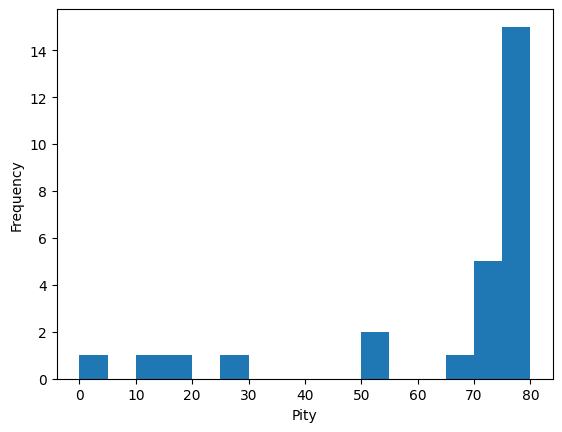

In [75]:
import matplotlib.pyplot as plt

bin_num = np.arange(0, grab_pity['Pity'].max() + 1, 5)
plt.figure()
grab_pity['Pity'].plot.hist(xlabel='Pity', bins=bin_num, color='tab:blue')

In [69]:
# Extract 5-star pity data for standard banner
grab_pity_standard = standard_pulls[standard_pulls['Rarity'] == 5].drop(columns=['Type', 'Time'])
grab_pity_standard

,Wish Result,Rarity,Pity
74,Skyward Atlas,5,11
120,Lost Prayer to the Sacred Winds,5,46
178,Diluc,5,58
200,Keqing,5,22
279,Aquila Favonia,5,79
328,Aquila Favonia,5,49
405,Tighnari,5,77
418,Skyward Spine,5,13


<Axes: xlabel='Pity', ylabel='Frequency'>

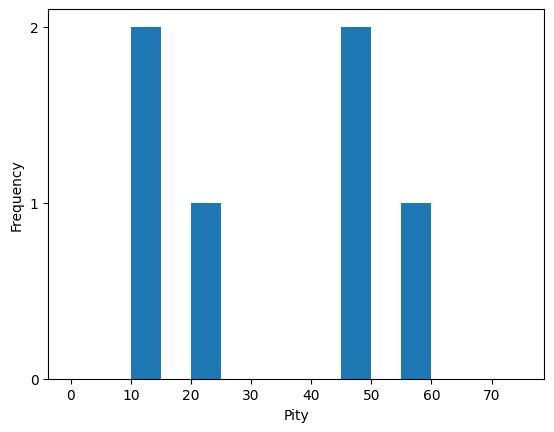

In [87]:
bin_num = np.arange(0, grab_pity_standard['Pity'].max() + 1, 5)
y_scale = np.arange(0, 3)
plt.figure()
grab_pity_standard['Pity'].plot.hist(xlabel='Pity', bins=bin_num, yticks=y_scale, color='tab:blue')